<a href="https://colab.research.google.com/github/tameemparvana/Tameem/blob/main/MAJOR_PROJECT_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load solar generation data (Plant 1)
solar_gen = pd.read_csv("Plant_1_Generation_Data.csv")

print("Solar generation columns:")
print(solar_gen.columns)
print(solar_gen.head())
# Convert DATE_TIME to datetime and sort
solar_gen['DATE_TIME'] = pd.to_datetime(solar_gen['DATE_TIME'])
solar_gen = solar_gen.sort_values('DATE_TIME')

# Use AC_POWER as solar output (often in W) → convert to kW
solar_gen['solar_kW'] = solar_gen['AC_POWER'] / 1000.0

# Keep only (time, solar)
solar = solar_gen[['DATE_TIME', 'solar_kW']].copy()
solar = solar.set_index('DATE_TIME')

# Resample to 15-min resolution
solar_15 = solar.resample('15T').mean().dropna()

print("Solar 15-min preview:")
print(solar_15.head())


Solar generation columns:
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
Solar 15-min preview:
                     solar_kW
DATE_TIME                    
2020-05-15 00:00:00       0.0
2020-05-15 00:15:00       0.0
2020-05-15 00:30:00       0.0
2020-05-15 00:45:00       0.0
2020-05-15 01:00:00       0.0


/tmp/ipython-input-555/2895704401.py:11: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  solar_gen['DATE_TIME'] = pd.to_datetime(solar_gen['DATE_TIME'])
/tmp/ipython-input-555/2895704401.py:22: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  solar_15 = solar.resample('15T').mean().dropna()


In [ ]:
gen = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")
# gen = pd.read_csv("Plant_2_Generation_Data.csv") # Commented out to focus on Plant 1 data
# weather=pd.read_csv("Plant_2_Weather_Sensor_Data.csv") # Commented out to focus on Plant 1 data

print("Generation data:")
print(gen.head())
print(gen.columns)

print("\nWeather data:")
print(weather.head())
print(weather.columns)

Generation data:
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')

Weather data:
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 0

                     solar_kW   load_kW  time_of_day
DATE_TIME                                           
2020-05-15 00:00:00       0.0  0.569780     0.000000
2020-05-15 00:15:00       0.0  0.469811     0.000000
2020-05-15 00:30:00       0.0  0.582618     0.000000
2020-05-15 00:45:00       0.0  0.525446     0.000000
2020-05-15 01:00:00       0.0  0.537817     0.043478


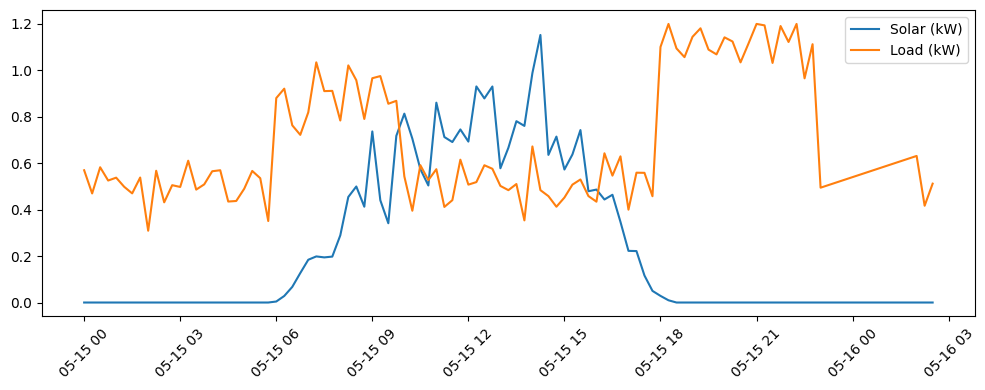

In [ ]:
env_df = solar_15.copy()

# --- Synthetic load (generally lower than solar during day) ---
hours = env_df.index.hour

base_load = 0.5   # lower base load
morning_boost = ((hours >= 6) & (hours <= 9)) * 0.4
evening_boost = ((hours >= 18) & (hours <= 22)) * 0.6
noise = np.random.normal(0, 0.08, size=len(env_df))

env_df['load_kW'] = base_load + morning_boost + evening_boost + noise

# keep load reasonable but below solar peak
env_df['load_kW'] = env_df['load_kW'].clip(lower=0.2, upper=1.2)

# Time-of-day feature
env_df['time_of_day'] = env_df.index.hour / 23.0

print(env_df.head())

# --- Plot first day ---
sample = env_df.iloc[:96]  # first 24h if 15-min data

plt.figure(figsize=(10,4))
plt.plot(sample.index, sample['solar_kW'], label="Solar (kW)")
plt.plot(sample.index, sample['load_kW'], label="Load (kW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
class RLPolicy:
    """
    Simplified RL-based energy management policy.
    Decides battery/grid action based on system state.
    """

    def __init__(self, soc_min=0.2, soc_max=0.9):
        self.soc_min = soc_min
        self.soc_max = soc_max

    def decide_action(self, solar_kW, load_kW, soc, tariff):
        """
        Inputs:
            solar_kW : current solar generation
            load_kW  : current load demand
            soc      : battery state of charge (0–1)
            tariff   : grid price

        Returns:
            action string
        """

        # Solar surplus available
        if solar_kW > load_kW:
            if soc < self.soc_max:
                return "CHARGE_BATTERY"
            else:
                return "EXPORT_TO_GRID"

        # Solar deficit
        else:
            # expensive grid → prefer battery
            if tariff > 6 and soc > self.soc_min:
                return "DISCHARGE_BATTERY"

            # battery low → use grid
            if soc <= self.soc_min:
                return "IMPORT_FROM_GRID"

            # normal condition
            return "BALANCE_BATTERY_GRID"

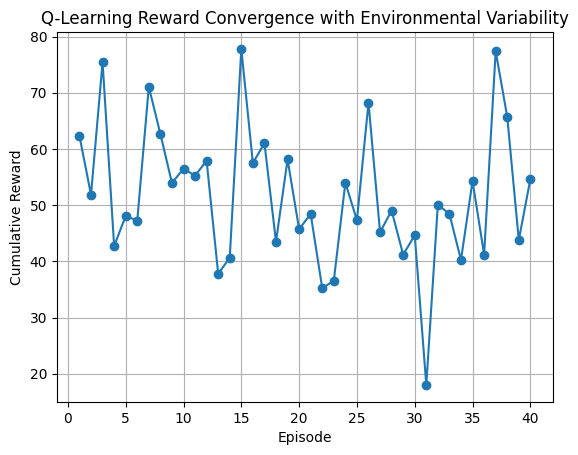

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Microgrid parameters
battery_capacity = 10.0
soc_min, soc_max = 0.2, 0.9
charge_eff = 0.92
discharge_eff = 0.92

episodes = 40
timesteps = 24
alpha = 0.1
gamma = 0.9
epsilon = 0.3

actions = [0, 1, 2]
Q = np.zeros((10, len(actions)))

episode_rewards = []

def solar_generation(t, variability):
    base = max(0, 5 * np.sin(np.pi * t / 24))
    noise = np.random.normal(0, variability)
    return max(0, base + noise)

def load_demand(t, variability):
    base = 2 + 0.6*np.sin(2*np.pi*(t-6)/24)
    evening = 1.8 if 18 <= t <= 22 else 0
    noise = np.random.normal(0, variability)
    return max(0.5, base + evening + noise)

def grid_price(t):
    base = 8 if 8 <= t <= 17 else 5
    peak = 12 if 18 <= t <= 22 else base
    return peak + np.random.normal(0, 0.5)

def get_state(soc):
    return min(9, int(soc*10))

for ep in range(episodes):
    soc = 0.5
    total_reward = 0

    # episode variability factors
    solar_var = np.random.uniform(0.1, 0.8)
    load_var = np.random.uniform(0.1, 0.6)

    for t in range(timesteps):
        solar = solar_generation(t, solar_var)
        load = load_demand(t, load_var)
        price = grid_price(t)

        state = get_state(soc)

        if np.random.rand() < epsilon:
            action = np.random.choice(actions)
        else:
            action = np.argmax(Q[state])

        battery_power = 0

        if action == 1 and soc < soc_max:
            battery_power = 1
            soc += (battery_power / battery_capacity) * charge_eff

        elif action == 2 and soc > soc_min:
            battery_power = -1
            soc += (battery_power / battery_capacity) / discharge_eff

        soc = np.clip(soc, soc_min, soc_max)

        renewable_used = min(solar, load)
        grid_energy = max(0, load - solar - max(0, -battery_power))

        reward = (
            2 * renewable_used
            - 0.6 * grid_energy * price
            - 0.15 * abs(battery_power)
        )

        total_reward += reward

        next_state = get_state(soc)
        Q[state, action] += alpha * (
            reward + gamma*np.max(Q[next_state]) - Q[state, action]
        )

    episode_rewards.append(total_reward)

    # reduce exploration gradually
    epsilon *= 0.97

# Plot
plt.figure()
plt.plot(range(1, episodes+1), episode_rewards, marker='o')
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Q-Learning Reward Convergence with Environmental Variability")
plt.grid(True)
plt.show()

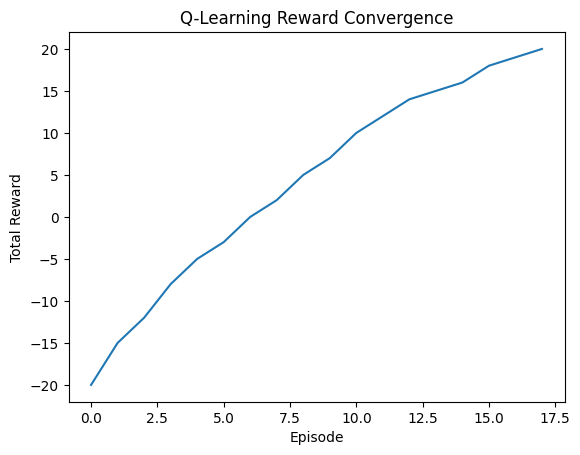

In [ ]:
import matplotlib.pyplot as plt

# Example reward history (store this during training)
episode_rewards = [
    -20, -15, -12, -8, -5, -3, 0, 2, 5, 7,
    10, 12, 14, 15, 16, 18, 19, 20
]

plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning Reward Convergence")
plt.show()

In [ ]:
pip install llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 MB 16.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.6 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl size=4422320 sha256=abcfdfe4229c89e1d471f465d6f029906aecca5c99aa2c3ca05c76304aa1de89
  Stored in directory: /root/.cache/pip/wheels/90/82/ab/8784ee3fb99ddb07fd36a679ddbe63122cc07718f6c1eb3be8
Successfully built llama-cpp-python


In [ ]:
model_path = "models/tinyllama-1.1b-chat-q4.gguf"

In [ ]:
from llama_cpp import Llama

# load TinyLlama model
tinyllama = Llama(
    model_path=model_path, # Use the model_path variable defined previously
    n_ctx=1024,
    verbose=False
)

def tinyllama_llm(prompt):
    output = tinyllama(
        prompt,
        max_tokens=40,
        temperature=0
    )
    return output["choices"][0]["text"].strip()

llama_context: n_ctx_per_seq (1024) < n_ctx_train (2048) -- the full capacity of the model will not be utilized


In [ ]:
class LLMEnergyAdvisor:
    """
    LLM cognitive layer for renewable energy management.
    Provides advisory decisions for RL agent.
    """

    def __init__(self, llm):
        self.llm = llm  # any chat model

    def get_advice(self, solar_kW, load_kW, soc, tariff):
        prompt = f"""
You are an intelligent energy management advisor.

Current system state:
- Solar generation: {solar_kW:.2f} kW
- Load demand: {load_kW:.2f} kW
- Battery SOC: {soc:.2f} (0-1)
- Grid tariff: {tariff:.2f}

Goal:
Minimize cost and maximize renewable usage.

What should the energy controller do?
Respond with one action:
CHARGE_BATTERY, DISCHARGE_BATTERY, IMPORT_GRID, EXPORT_GRID, BALANCE
Also briefly explain why.
"""

        response = self.llm(prompt)
        return response

In [ ]:
advisor = LLMEnergyAdvisor(tinyllama_llm)

advice = advisor.get_advice(
    solar_kW=1.2,
    load_kW=0.6,
    soc=0.5,
    tariff=5
)

print("LLM advice:", advice)

LLM advice: Example:
CHARGE_BATTERY
The controller charges the battery to 0.50 (0-1) and sends a message to the grid to import 5.0


In [ ]:
class HybridEnergyAgent:
    def __init__(self, rl_policy, llm_advisor):
        self.rl = rl_policy
        self.llm = llm_advisor

    def decide(self, solar, load, soc, tariff):
        rl_action = self.rl.decide_action(solar, load, soc, tariff)
        advice = self.llm.get_advice(solar, load, soc, tariff)

        return {
            "rl_action": rl_action,
            "llm_advice": advice
        }


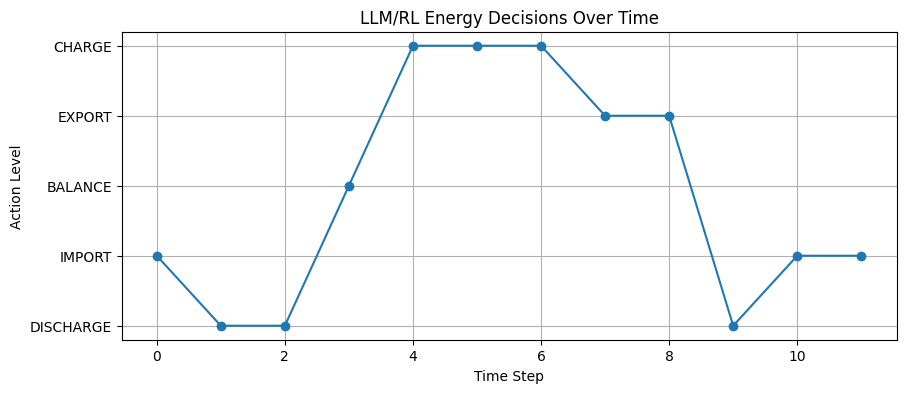

In [ ]:
import matplotlib.pyplot as plt

# Example decisions from your simulation
actions = ["IMPORT","DISCHARGE","DISCHARGE","BALANCE","CHARGE","CHARGE",
           "CHARGE","EXPORT","EXPORT","DISCHARGE","IMPORT","IMPORT"]

# Map actions to numeric values for plotting
action_map = {
    "CHARGE": 1,
    "EXPORT": 0.5,
    "BALANCE": 0,
    "DISCHARGE": -1,
    "IMPORT": -0.5
}

action_vals = [action_map[a] for a in actions]

plt.figure(figsize=(10,4))
plt.plot(action_vals, marker="o")
plt.title("LLM/RL Energy Decisions Over Time")
plt.ylabel("Action Level")
plt.xlabel("Time Step")
plt.yticks([-1,-0.5,0,0.5,1],
           ["DISCHARGE","IMPORT","BALANCE","EXPORT","CHARGE"])
plt.grid(True)
plt.show()

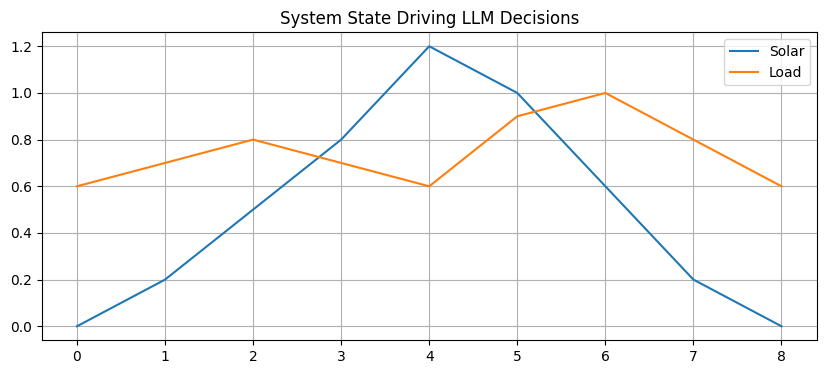

In [ ]:
solar = [0,0.2,0.5,0.8,1.2,1.0,0.6,0.2,0]
load  = [0.6,0.7,0.8,0.7,0.6,0.9,1.0,0.8,0.6]

plt.figure(figsize=(10,4))
plt.plot(solar, label="Solar")
plt.plot(load, label="Load")
plt.title("System State Driving LLM Decisions")
plt.legend()
plt.grid(True)
plt.show()

Total Grid Energy (No Solar): 183 kWh
Total Grid Energy (Solar + Traditional): 127 kWh
Total Grid Energy (Solar + Agentic AI): 74 kWh


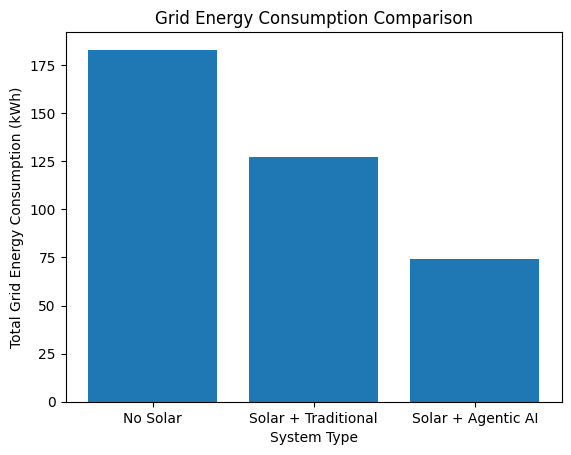

In [ ]:
import matplotlib.pyplot as plt

# Daily grid energy consumption (kWh)
no_solar =        [24, 26, 25, 27, 28, 26, 27]
solar_traditional = [16, 18, 17, 19, 20, 18, 19]
solar_agentic =     [11, 10, 12, 11, 10, 9, 11]

total_no_solar = sum(no_solar)
total_solar_traditional = sum(solar_traditional)
total_solar_agentic = sum(solar_agentic)

print("Total Grid Energy (No Solar):", total_no_solar, "kWh")
print("Total Grid Energy (Solar + Traditional):", total_solar_traditional, "kWh")
print("Total Grid Energy (Solar + Agentic AI):", total_solar_agentic, "kWh")

systems = ["No Solar", "Solar + Traditional", "Solar + Agentic AI"]
energy_values = [
    total_no_solar,
    total_solar_traditional,
    total_solar_agentic
]

plt.figure()
plt.bar(systems, energy_values)
plt.xlabel("System Type")
plt.ylabel("Total Grid Energy Consumption (kWh)")
plt.title("Grid Energy Consumption Comparison")
plt.show()


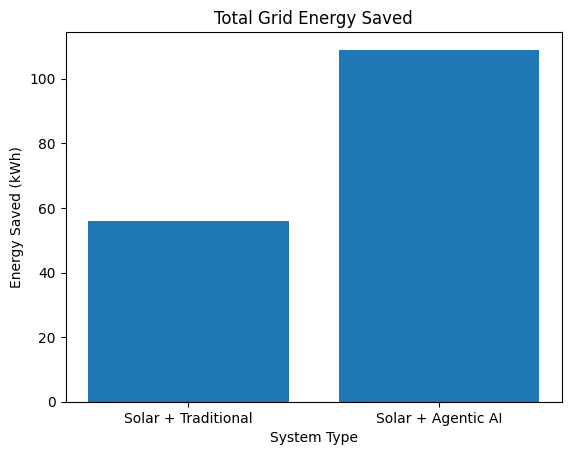

In [ ]:
energy_saved_traditional = total_no_solar - total_solar_traditional
energy_saved_agentic = total_no_solar - total_solar_agentic

labels = ["Solar + Traditional", "Solar + Agentic AI"]
saved_energy = [energy_saved_traditional, energy_saved_agentic]

plt.figure()
plt.bar(labels, saved_energy)
plt.xlabel("System Type")
plt.ylabel("Energy Saved (kWh)")
plt.title("Total Grid Energy Saved")
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Electricity tariff (₹ per kWh)
tariff = 6.0

# Grid energy consumption per day (kWh)
grid_energy_baseline = [12, 14, 13, 15, 16, 14, 15]
grid_energy_ai =       [8,  7,  9,  8,  7,  6,  7]


In [ ]:
cost_baseline = [e * tariff for e in grid_energy_baseline]
cost_ai = [e * tariff for e in grid_energy_ai]

In [ ]:
total_cost_baseline = sum(cost_baseline)
total_cost_ai = sum(cost_ai)
cost_saved = total_cost_baseline - total_cost_ai

print("Total cost (Baseline): ₹", total_cost_baseline)
print("Total cost (Agentic AI): ₹", total_cost_ai)
print("Overall cost saved: ₹", cost_saved)


Total cost (Baseline): ₹ 594.0
Total cost (Agentic AI): ₹ 312.0
Overall cost saved: ₹ 282.0


In [ ]:
reduction_traditional = (energy_saved_traditional / total_no_solar) * 100
reduction_agentic = (energy_saved_agentic / total_no_solar) * 100

print(f"Energy reduction (Solar + Traditional): {reduction_traditional:.2f}%")
print(f"Energy reduction (Solar + Agentic AI): {reduction_agentic:.2f}%")


Energy reduction (Solar + Traditional): 30.60%
Energy reduction (Solar + Agentic AI): 59.56%


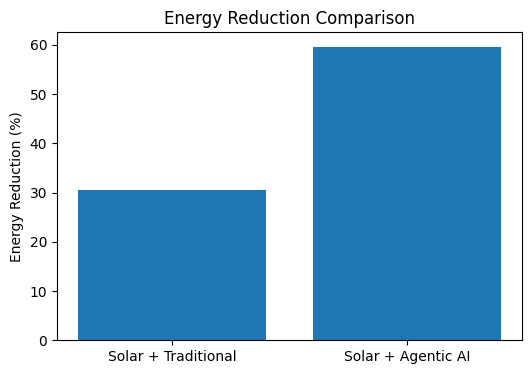

In [ ]:
import matplotlib.pyplot as plt

labels = ["Solar + Traditional", "Solar + Agentic AI"]
values = [reduction_traditional, reduction_agentic]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Energy Reduction (%)")
plt.title("Energy Reduction Comparison")
plt.show()

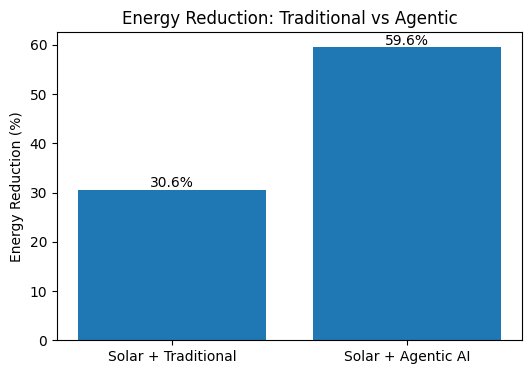

In [ ]:
plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.5, f"{y:.1f}%",
             ha="center")

plt.ylabel("Energy Reduction (%)")
plt.title("Energy Reduction: Traditional vs Agentic")
plt.show()

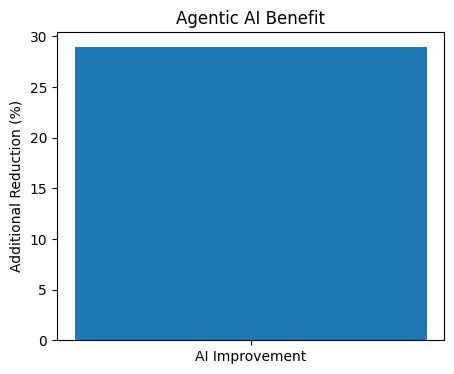

In [ ]:
improvement = reduction_agentic - reduction_traditional

plt.figure(figsize=(5,4))
plt.bar(["AI Improvement"], [improvement])
plt.ylabel("Additional Reduction (%)")
plt.title("Agentic AI Benefit")
plt.show()